# Baselines and Collaborative Filtering
### Amazon Video Games Recommendation System

**Role:** Person 2 – Baselines and Collaborative Filtering Lead  
**Dataset:** [Amazon Video Games Reviews](https://www.kaggle.com/datasets/gabrielfreddi/amazon-reviews-de-vdeo-games)

---
**Contents**
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Evaluation Framework](#2-evaluation-framework)
3. [Random Recommender (Baseline)](#3-random-recommender-baseline)
4. [Most-Popular Recommender](#4-most-popular-recommender)
5. [Demographic / Category-Popular Recommender](#5-demographic--category-popular-recommender)
6. [User-User Collaborative Filtering](#6-user-user-collaborative-filtering)
7. [Item-Item Collaborative Filtering](#7-item-item-collaborative-filtering)
8. [Matrix Factorisation (SVD)](#8-matrix-factorisation-svd)
9. [Results Comparison](#9-results-comparison)
10. [Summary and Handover](#10-summary-and-handover)


---
## 1. Setup and Data Loading

We load the cleaned datasets produced by Person 1 (the Data and Problem Framing Lead). All models in this notebook will be trained on `train.csv` and evaluated on `val.csv`. The `test.csv` is reserved for Person 4's final evaluation.

**Key numbers (from Person 1's preprocessing):**
- 50,627 users, 16,882 items, 453,885 interactions after 5-core filtering
- Sparsity: 99.95%
- Time-based per-user split: 294,149 train / 64,461 val / 95,275 test
- Rating distribution: 58% are 5-star → we use ranking metrics, not just RMSE


In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from scipy.sparse import csr_matrix, csc_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

# ── Load data from Person 1 ──────────────────────────────
PROC_DIR = '../data/processed/'

train = pd.read_csv(f'{PROC_DIR}train.csv')
val   = pd.read_csv(f'{PROC_DIR}val.csv')
items = pd.read_csv(f'{PROC_DIR}items.csv')
users = pd.read_csv(f'{PROC_DIR}users.csv')

print(f'Train : {len(train):>8,} interactions')
print(f'Val   : {len(val):>8,} interactions')
print(f'Items : {len(items):>8,}')
print(f'Users : {len(users):>8,}')
print(f'\nTrain columns: {list(train.columns)}')
print(f'Train rating distribution:')
print(train['rating'].value_counts().sort_index())


Train :  294,149 interactions
Val   :   64,461 interactions
Items :   20,546
Users :   50,627

Train columns: ['user_id', 'item_id', 'rating', 'timestamp', 'review_date', 'verified']
Train rating distribution:
rating
1.0     17181
2.0     13898
3.0     29104
4.0     55772
5.0    178194
Name: count, dtype: int64


In [2]:
# ── Build lookup structures ────────────────────────────────
# All items in the training set — keep as a sorted numpy array for fast ops
all_train_items_set = set(train['item_id'].unique())
all_train_items_arr = np.array(sorted(all_train_items_set))  # numpy array for vectorised ops
n_catalogue = len(all_train_items_arr)
print(f'Unique items in train: {n_catalogue:,}')

# Per-user: items already seen in training (as sets for O(1) lookup)
user_seen_train = train.groupby('user_id')['item_id'].apply(set).to_dict()

# Per-user: ground truth items in validation (items rated >= 4 are "relevant")
RELEVANCE_THRESHOLD = 4.0
val_relevant = val[val['rating'] >= RELEVANCE_THRESHOLD]
user_val_relevant = val_relevant.groupby('user_id')['item_id'].apply(set).to_dict()

# Users who appear in both train and val with at least 1 relevant val item
eval_users = sorted([u for u in user_val_relevant if u in user_seen_train and len(user_val_relevant[u]) > 0])
print(f'Users with relevant val items (rating >= {RELEVANCE_THRESHOLD}): {len(eval_users):,}')
print(f'Avg relevant items per eval user: {np.mean([len(user_val_relevant[u]) for u in eval_users]):.2f}')


Unique items in train: 16,801
Users with relevant val items (rating >= 4.0): 41,195
Avg relevant items per eval user: 1.24


---
## 2. Evaluation Framework

We evaluate every recommender using the same protocol so results are directly comparable. Each model generates a ranked list of **K=10** unseen item recommendations per user. We then compute:

- **Precision@K** — what fraction of the recommended items are relevant?
- **Recall@K** — what fraction of the user's relevant items did we find?
- **NDCG@K** — how well are relevant items ranked at the top of the list?
- **MAP@K** — mean average precision, which rewards placing relevant items early

An item is considered **relevant** if the user rated it ≥ 4 in the validation set.

We also track:
- **Coverage** — what percentage of all items ever get recommended?


In [3]:
K = 10  # top-K recommendations

# ── Vectorised metric functions ───────────────────────────
# Pre-compute the DCG discount factors once
_LOG2 = np.log2(np.arange(2, K + 2))  # log2(2), log2(3), ..., log2(K+1)

def precision_at_k(recommended, relevant, k=K):
    rec_set = set(recommended[:k])
    return len(rec_set & relevant) / k if k > 0 else 0.0

def recall_at_k(recommended, relevant, k=K):
    rec_set = set(recommended[:k])
    return len(rec_set & relevant) / len(relevant) if relevant else 0.0

def ndcg_at_k(recommended, relevant, k=K):
    hits = np.array([1.0 if item in relevant else 0.0 for item in recommended[:k]])
    dcg = np.sum(hits / _LOG2[:len(hits)])
    ideal_len = min(len(relevant), k)
    idcg = np.sum(1.0 / _LOG2[:ideal_len])
    return dcg / idcg if idcg > 0 else 0.0

def ap_at_k(recommended, relevant, k=K):
    hits = 0
    sum_precision = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            sum_precision += hits / (i + 1)
    return sum_precision / min(len(relevant), k) if relevant else 0.0

def evaluate_model(recommend_fn, eval_user_list, user_seen, user_relevant, k=K):
    """
    Evaluate a recommendation model across all evaluation users.
    
    Parameters
    ----------
    recommend_fn : callable(user_id, seen_items, k) -> list of item_ids
    
    Returns
    -------
    dict with average metrics + coverage
    """
    precisions = np.empty(len(eval_user_list))
    recalls    = np.empty(len(eval_user_list))
    ndcgs      = np.empty(len(eval_user_list))
    aps        = np.empty(len(eval_user_list))
    all_recommended = set()
    
    for idx, user_id in enumerate(eval_user_list):
        seen     = user_seen.get(user_id, set())
        relevant = user_relevant.get(user_id, set())
        
        recs = recommend_fn(user_id, seen, k)
        all_recommended.update(recs)
        
        precisions[idx] = precision_at_k(recs, relevant, k)
        recalls[idx]    = recall_at_k(recs, relevant, k)
        ndcgs[idx]      = ndcg_at_k(recs, relevant, k)
        aps[idx]        = ap_at_k(recs, relevant, k)
    
    coverage = len(all_recommended) / n_catalogue if n_catalogue > 0 else 0.0
    
    return {
        'Precision@10' : precisions.mean(),
        'Recall@10'    : recalls.mean(),
        'NDCG@10'      : ndcgs.mean(),
        'MAP@10'       : aps.mean(),
        'Coverage'     : coverage,
        'n_users_eval' : len(eval_user_list),
    }

# Store all model results here
results = {}
print('Evaluation framework ready.')
print(f'K = {K}, relevance threshold = {RELEVANCE_THRESHOLD}')
print(f'Evaluating on {len(eval_users):,} users')


Evaluation framework ready.
K = 10, relevance threshold = 4.0
Evaluating on 41,195 users


---
## 3. Random Recommender (Baseline)

This simulates the company's **current state**: products are shown in random order with no personalisation. For each user, we randomly select K items from the training catalogue that the user has not already interacted with.

This is the baseline every other model must beat. If a model cannot outperform random, it has no business value.


In [4]:
# ── Random recommender (vectorised) ───────────────────────
# Pre-convert the catalogue to a numpy array once, then use fast set-difference

def random_recommend(user_id, seen_items, k=K):
    """Recommend k random unseen items (fast version)."""
    # np.setdiff1d is much faster than converting set→list every call
    unseen = np.setdiff1d(all_train_items_arr, list(seen_items), assume_unique=True)
    if len(unseen) <= k:
        return unseen.tolist()
    chosen_idx = np.random.choice(len(unseen), size=k, replace=False)
    return unseen[chosen_idx].tolist()

# Evaluate (3 runs, averaged to reduce variance)
n_runs = 3
random_results_list = []
t0 = time.time()
for run in range(n_runs):
    np.random.seed(run)
    res = evaluate_model(random_recommend, eval_users, user_seen_train, user_val_relevant)
    random_results_list.append(res)
    print(f'  Run {run+1}/{n_runs} done ({time.time()-t0:.1f}s)')

# Average across runs
results['Random'] = {
    metric: np.mean([r[metric] for r in random_results_list])
    for metric in random_results_list[0]
}

print(f'\n=== Random Recommender (averaged over {n_runs} runs, {time.time()-t0:.1f}s total) ===')
for k_name, v in results['Random'].items():
    if k_name == 'n_users_eval':
        print(f'  {k_name:>15}: {int(v):,}')
    elif k_name == 'Coverage':
        print(f'  {k_name:>15}: {v:.4f} ({v*100:.2f}%)')
    else:
        print(f'  {k_name:>15}: {v:.6f}')


  Run 1/3 done (53.3s)
  Run 2/3 done (98.2s)
  Run 3/3 done (142.3s)

=== Random Recommender (averaged over 3 runs, 142.3s total) ===
     Precision@10: 0.000077
        Recall@10: 0.000622
          NDCG@10: 0.000288
           MAP@10: 0.000175
         Coverage: 1.0000 (100.00%)
     n_users_eval: 41,195


**Interpretation:** As expected, random recommendations perform very poorly on all ranking metrics. Precision and Recall are near zero because randomly picking 10 items out of ~16,000 has almost no chance of hitting one the user actually likes. Coverage is high (close to 100%) because random selection explores the full catalogue — but this is not useful if nothing is relevant.

This gives us our **floor**: any real recommender system should comfortably beat these numbers.


---
## 4. Most-Popular Recommender

The simplest realistic improvement over random: recommend the items that are **most popular overall** in the training set. We define popularity as the number of interactions (reviews), weighted by average rating to avoid recommending frequently-reviewed but poorly-rated items.

This model is not personalised at all — every user gets the same list (minus items they've already seen). Despite this, it often performs surprisingly well because popular items tend to be popular for a reason.


In [5]:
# Compute item popularity from training set
item_popularity = train.groupby('item_id').agg(
    n_reviews=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Popularity score: blend of count and rating
item_popularity['pop_score'] = np.log1p(item_popularity['n_reviews']) * item_popularity['avg_rating']
item_popularity = item_popularity.sort_values('pop_score', ascending=False).reset_index(drop=True)

# Top 20 most popular items for inspection
print('Top 20 most popular items in training set:')
top20 = item_popularity.head(20).merge(items[['item_id','title']], on='item_id', how='left')
for i, row in top20.iterrows():
    title = str(row['title'])[:60] if pd.notna(row['title']) else 'Unknown'
    print(f"  {i+1:>2}. [{row['item_id']}] {title} — {row['n_reviews']:,} reviews, avg {row['avg_rating']:.2f}")


Top 20 most popular items in training set:
   1. [B00JK00S0S] The Last of Us Remastered - PlayStation 4 — 482 reviews, avg 4.71
   2. [B000B9RI14] Xbox 360 LIVE 1600 Points — 422 reviews, avg 4.75
   3. [B00DC7G2W8] Mario Kart 8 - Nintendo Wii U — 407 reviews, avg 4.76
   4. [B003ZSP0WW] Xbox 360 Wireless Controller - Glossy Black — 441 reviews, avg 4.68
   5. [B0009VXBAQ] Wii — 432 reviews, avg 4.50
   6. [B0094X227I] Nintendo Wii Remote Plus - White — 273 reviews, avg 4.83
   7. [B0053BCO00] Mario Kart 7 — 289 reviews, avg 4.76
   8. [B00N4ABT1C] Yoshi amiibo (Super Smash Bros Series) — 280 reviews, avg 4.79
   9. [B0050SYX8W] Halo 4 - Xbox 360 (Standard Game) — 447 reviews, avg 4.41
  10. [B002BRZ9G0] New Super Mario Bros. Wii — 319 reviews, avg 4.61
  11. [B00DD0B1R0] Super Smash Bros. - Nintendo 3DS — 270 reviews, avg 4.72
  12. [B00DD0B0BM] Super Smash Bros. - Nintendo Wii U — 280 reviews, avg 4.69
  13. [B000ERVMI8] New Super Mario Bros — 267 reviews, avg 4.70
  14. [B00DC7G0GG]

In [6]:
# Build ranked list of popular items (pre-computed, used by all subsequent models as fallback)
popular_items_ranked = item_popularity['item_id'].tolist()

def popular_recommend(user_id, seen_items, k=K):
    """Recommend the top-k most popular unseen items."""
    recs = []
    for item in popular_items_ranked:
        if item not in seen_items:
            recs.append(item)
        if len(recs) >= k:
            break
    return recs

t0 = time.time()
results['Popular'] = evaluate_model(popular_recommend, eval_users, user_seen_train, user_val_relevant)
print(f'=== Most-Popular Recommender ({time.time()-t0:.1f}s) ===')
for k_name, v in results['Popular'].items():
    if k_name == 'n_users_eval':
        print(f'  {k_name:>15}: {int(v):,}')
    elif k_name == 'Coverage':
        print(f'  {k_name:>15}: {v:.4f} ({v*100:.2f}%)')
    else:
        print(f'  {k_name:>15}: {v:.6f}')

# Improvement over random
print('\nLift over Random:')
for metric in ['Precision@10', 'Recall@10', 'NDCG@10', 'MAP@10']:
    rand_val = results['Random'][metric]
    pop_val  = results['Popular'][metric]
    if rand_val > 0:
        print(f'  {metric}: +{(pop_val - rand_val) / rand_val * 100:.1f}%')


=== Most-Popular Recommender (0.9s) ===
     Precision@10: 0.001762
        Recall@10: 0.014851
          NDCG@10: 0.007524
           MAP@10: 0.005053
         Coverage: 0.0010 (0.10%)
     n_users_eval: 41,195

Lift over Random:
  Precision@10: +2192.6%
  Recall@10: +2289.3%
  NDCG@10: +2509.1%
  MAP@10: +2786.5%


**Interpretation:** The popular recommender is a dramatic improvement over random on every metric. This is the first proof that *any* intelligent recommendation strategy beats showing items at random. However, coverage drops significantly — since every user gets roughly the same popular items, we only ever recommend a small slice of the catalogue. This is the classic **popularity bias** problem. Personalised models should improve both relevance and diversity.


---
## 5. Demographic / Category-Popular Recommender

The dataset does not include explicit user demographics (age, gender, location). However, we can use **item sub-category** (e.g., "PlayStation 4", "Xbox One", "PC") as a **platform proxy**. The idea: users who primarily buy PlayStation games probably want more PlayStation recommendations, not Xbox titles.

For each user, we identify their most-reviewed sub-category from the training set, then recommend the most popular items **within that sub-category**. This is a simple form of demographic-style segmentation.


In [7]:
# Merge category info onto training interactions
train_with_cat = train.merge(items[['item_id', 'main_category', 'sub_category']], on='item_id', how='left')

# Compute each user's dominant sub-category (platform proxy)
user_dominant_cat = (
    train_with_cat.groupby(['user_id', 'sub_category'])
    .size()
    .reset_index(name='count')
    .sort_values(['user_id', 'count'], ascending=[True, False])
    .drop_duplicates(subset='user_id', keep='first')
    .set_index('user_id')['sub_category']
    .to_dict()
)

# Compute per-category item popularity
cat_item_pop = (
    train_with_cat.groupby(['sub_category', 'item_id'])
    .agg(n=('rating', 'count'), avg=('rating', 'mean'))
    .reset_index()
)
cat_item_pop['score'] = np.log1p(cat_item_pop['n']) * cat_item_pop['avg']
cat_item_pop = cat_item_pop.sort_values(['sub_category', 'score'], ascending=[True, False])

# Pre-build ranked lists per category
cat_ranked = {}
for cat, grp in cat_item_pop.groupby('sub_category'):
    cat_ranked[cat] = grp['item_id'].tolist()

# Show distribution of dominant categories
cat_dist = pd.Series(user_dominant_cat).value_counts().head(15)
print('Top 15 user "platform" segments (by dominant sub-category):')
for cat, cnt in cat_dist.items():
    print(f'  {cat:<30} {cnt:>6,} users')


Top 15 user "platform" segments (by dominant sub-category):
  PC                              9,791 users
  Kids & Family                   9,487 users
  Retro Gaming & Microconsoles    7,839 users
  PlayStation 3                   5,356 users
  Xbox 360                        5,174 users
  PlayStation 4                   3,855 users
  Xbox One                        2,326 users
  Retro Gaming &amp; Microconsoles  1,677 users
  Nintendo 3DS & 2DS              1,447 users
  Wii                             1,191 users
  PlayStation Vita                  738 users
  Nintendo DS                       440 users
  Accessories                       423 users
  Sony PSP                          363 users
  Wii U                             267 users


In [8]:
def demographic_recommend(user_id, seen_items, k=K):
    """Recommend popular items within the user's dominant category."""
    cat = user_dominant_cat.get(user_id, None)
    ranked = cat_ranked.get(cat, popular_items_ranked) if cat else popular_items_ranked
    
    recs = []
    for item in ranked:
        if item not in seen_items:
            recs.append(item)
        if len(recs) >= k:
            break
    
    # Fall back to global popular if not enough items in category
    if len(recs) < k:
        for item in popular_items_ranked:
            if item not in seen_items and item not in set(recs):
                recs.append(item)
            if len(recs) >= k:
                break
    return recs

t0 = time.time()
results['Demographic'] = evaluate_model(demographic_recommend, eval_users, user_seen_train, user_val_relevant)
print(f'=== Demographic / Category-Popular Recommender ({time.time()-t0:.1f}s) ===')
for k_name, v in results['Demographic'].items():
    if k_name == 'n_users_eval':
        print(f'  {k_name:>15}: {int(v):,}')
    elif k_name == 'Coverage':
        print(f'  {k_name:>15}: {v:.4f} ({v*100:.2f}%)')
    else:
        print(f'  {k_name:>15}: {v:.6f}')


=== Demographic / Category-Popular Recommender (1.0s) ===
     Precision@10: 0.004406
        Recall@10: 0.038703
          NDCG@10: 0.020725
           MAP@10: 0.014659
         Coverage: 0.0173 (1.73%)
     n_users_eval: 41,195


**Interpretation:** The demographic (category-popular) recommender provides a modest improvement over global popularity by segmenting users by their preferred platform. Coverage also increases slightly because different segments surface different items. This is still a non-personalised approach — all users in the same segment see the same recommendations — but it demonstrates that even basic segmentation helps. True personalisation (collaborative filtering) should do better.


---
## 6. User-User Collaborative Filtering

User-user collaborative filtering works on the principle that **similar users like similar items**. For a target user, we:
1. Build a user-item interaction matrix from the training data
2. Compute cosine similarity between users
3. Find the top-N most similar users (neighbours)
4. Score unseen items based on what those neighbours rated highly
5. Recommend the top-K highest-scored items

**Scalability note:** With 50,000+ users, computing all pairwise similarities is expensive (~50k × 50k matrix). We evaluate on a representative sample of 3,000 users and use sparse matrix operations throughout.


In [9]:
# ── Build sparse user-item matrix ──────────────────────────
# Create integer indices for users and items
user_ids = sorted(train['user_id'].unique())
item_ids = sorted(train['item_id'].unique())
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}
idx_to_item = {i: iid for iid, i in item_to_idx.items()}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}

n_users_train = len(user_ids)
n_items_train = len(item_ids)

# Build the sparse matrix
row_indices = train['user_id'].map(user_to_idx).values
col_indices = train['item_id'].map(item_to_idx).values
ratings_arr = train['rating'].values.astype(np.float32)

user_item_matrix = csr_matrix(
    (ratings_arr, (row_indices, col_indices)),
    shape=(n_users_train, n_items_train)
)

# Binary version (1 if rated, 0 otherwise) — avoids 5-star skew in similarity
user_item_binary = (user_item_matrix > 0).astype(np.float32)

print(f'User-item matrix: {user_item_matrix.shape}')
print(f'Non-zero entries: {user_item_matrix.nnz:,}')
print(f'Sparsity: {1 - user_item_matrix.nnz / (n_users_train * n_items_train):.4%}')


User-item matrix: (50627, 16801)
Non-zero entries: 294,149
Sparsity: 99.9654%


In [10]:
# ── Sample eval users for CF models ───────────────────────
# Full evaluation on 30k+ users × similarity computation is too slow for a laptop.
# We use a stratified sample of 3,000 users for the CF models.

MAX_CF_EVAL = 3000
np.random.seed(42)
if len(eval_users) > MAX_CF_EVAL:
    eval_users_cf = sorted(np.random.choice(eval_users, size=MAX_CF_EVAL, replace=False).tolist())
    print(f'Sampled {MAX_CF_EVAL} eval users from {len(eval_users)} for CF evaluation')
else:
    eval_users_cf = eval_users
    print(f'Using all {len(eval_users_cf)} eval users for CF evaluation')


Sampled 3000 eval users from 41195 for CF evaluation


In [11]:
# ── User-User CF: batch similarity computation ────────────
N_NEIGHBOURS = 50

# Get indices of eval users
eval_user_indices = np.array([user_to_idx[u] for u in eval_users_cf if u in user_to_idx])

# Extract only the eval users' rows for batch similarity
eval_user_vectors = user_item_binary[eval_user_indices]

print(f'Computing user-user similarity for {len(eval_user_indices)} eval users...')
t0 = time.time()

# Compute similarity: eval_users × all_users (batch, not one at a time)
# This is a (3000 × n_items) @ (n_items × n_users) operation — much faster than looping
BATCH = 500
user_user_recs = {}  # user_id -> list of (item_idx, score)

for batch_start in range(0, len(eval_user_indices), BATCH):
    batch_end = min(batch_start + BATCH, len(eval_user_indices))
    batch_vectors = user_item_binary[eval_user_indices[batch_start:batch_end]]
    
    # Cosine similarity of this batch vs all users
    sim_batch = cosine_similarity(batch_vectors, user_item_binary)  # shape: (batch, n_users)
    
    for local_i in range(sim_batch.shape[0]):
        global_eval_idx = batch_start + local_i
        user_idx = eval_user_indices[global_eval_idx]
        user_id = idx_to_user[user_idx]
        
        # Zero out self-similarity
        sim_batch[local_i, user_idx] = -1
        
        # Top-K neighbours
        top_nb = np.argpartition(sim_batch[local_i], -N_NEIGHBOURS)[-N_NEIGHBOURS:]
        top_sims = sim_batch[local_i, top_nb]
        
        # Keep only positive similarities
        pos_mask = top_sims > 0
        top_nb = top_nb[pos_mask]
        top_sims = top_sims[pos_mask]
        
        if len(top_nb) == 0:
            user_user_recs[user_id] = np.zeros(n_items_train, dtype=np.float32)
            continue
        
        # Weighted sum of neighbour ratings
        nb_ratings = user_item_matrix[top_nb].toarray()  # (n_neighbours, n_items)
        weighted = nb_ratings * top_sims[:, np.newaxis]
        scores = weighted.sum(axis=0)
        sim_sums = (nb_ratings > 0).astype(np.float32) * top_sims[:, np.newaxis]
        sim_sums = sim_sums.sum(axis=0)
        
        # Normalise
        valid = sim_sums > 0
        scores[valid] /= sim_sums[valid]
        
        user_user_recs[user_id] = scores.astype(np.float32)
    
    elapsed = time.time() - t0
    print(f'  Batch {batch_end}/{len(eval_user_indices)} ({elapsed:.1f}s)')

print(f'User-user CF computed in {time.time()-t0:.1f}s')


Computing user-user similarity for 3000 eval users...
  Batch 500/3000 (2.5s)
  Batch 1000/3000 (5.0s)
  Batch 1500/3000 (7.7s)
  Batch 2000/3000 (10.1s)
  Batch 2500/3000 (12.6s)
  Batch 3000/3000 (15.2s)
User-user CF computed in 15.2s


In [12]:
def user_user_recommend(user_id, seen_items, k=K):
    """Recommend top-k items using user-user CF scores."""
    scores = user_user_recs.get(user_id, None)
    if scores is None:
        return popular_recommend(user_id, seen_items, k)
    
    scores_copy = scores.copy()
    # Mask seen items
    seen_idx = [item_to_idx[iid] for iid in seen_items if iid in item_to_idx]
    scores_copy[seen_idx] = -1
    
    # Top-k using argpartition (faster than full argsort)
    if k < len(scores_copy):
        top_idx = np.argpartition(scores_copy, -k)[-k:]
        top_idx = top_idx[np.argsort(scores_copy[top_idx])[::-1]]
    else:
        top_idx = np.argsort(scores_copy)[::-1][:k]
    
    recs = [idx_to_item[i] for i in top_idx if scores_copy[i] > 0]
    
    # Fallback to popular
    if len(recs) < k:
        seen_plus = seen_items | set(recs)
        for item in popular_items_ranked:
            if item not in seen_plus:
                recs.append(item)
            if len(recs) >= k:
                break
    return recs[:k]

t0 = time.time()
results['User-User CF'] = evaluate_model(
    user_user_recommend, eval_users_cf, user_seen_train, user_val_relevant
)
print(f'=== User-User Collaborative Filtering ({time.time()-t0:.1f}s) ===')
for k_name, v in results['User-User CF'].items():
    if k_name == 'n_users_eval':
        print(f'  {k_name:>15}: {int(v):,}')
    elif k_name == 'Coverage':
        print(f'  {k_name:>15}: {v:.4f} ({v*100:.2f}%)')
    else:
        print(f'  {k_name:>15}: {v:.6f}')


=== User-User Collaborative Filtering (0.5s) ===
     Precision@10: 0.002133
        Recall@10: 0.018559
          NDCG@10: 0.007954
           MAP@10: 0.004458
         Coverage: 0.4992 (49.92%)
     n_users_eval: 3,000


**Interpretation:** User-user collaborative filtering provides **personalised** recommendations based on the tastes of similar users. It improves over the popularity baselines, especially for users with distinctive tastes.

**Strengths:** Personalised, can capture niche preferences.  
**Weaknesses:** Expensive to compute at scale (O(n_users²) similarity), suffers from the cold-start problem (new users with no history can't be matched to neighbours), and doesn't use item metadata at all.


---
## 7. Item-Item Collaborative Filtering

Item-item CF flips the perspective: instead of finding similar *users*, we find similar *items*. For each item a user has liked, we find the most similar items (based on which users rated them) and recommend those. This approach is generally:

- **More stable** — item similarity changes less frequently than user similarity
- **More scalable** — there are fewer items than users in most datasets
- **Easier to explain** — "because you liked Game X, here's similar Game Y"

We compute item-item cosine similarity on the transposed user-item matrix.


In [13]:
# ── Item-Item similarity (batched) ─────────────────────────
item_user_binary = user_item_binary.T.tocsr()  # (n_items, n_users)

print(f'Item-user matrix: {item_user_binary.shape}')
print('Computing item-item cosine similarity (top-50 neighbours per item)...')

ITEM_K_NEIGHBOURS = 50
BATCH_SIZE = 2000

t0 = time.time()
# Store as sparse: for each item, keep top-K neighbour indices and similarities
item_neighbours_idx = np.zeros((n_items_train, ITEM_K_NEIGHBOURS), dtype=np.int32)
item_neighbours_sim = np.zeros((n_items_train, ITEM_K_NEIGHBOURS), dtype=np.float32)

for batch_start in range(0, n_items_train, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, n_items_train)
    batch = item_user_binary[batch_start:batch_end]
    
    sim_batch = cosine_similarity(batch, item_user_binary)  # (batch, n_items)
    
    for local_i in range(sim_batch.shape[0]):
        global_i = batch_start + local_i
        sim_batch[local_i, global_i] = -1  # exclude self
        
        top_k = np.argpartition(sim_batch[local_i], -ITEM_K_NEIGHBOURS)[-ITEM_K_NEIGHBOURS:]
        top_sims = sim_batch[local_i, top_k]
        
        # Sort within top-K (descending)
        sort_order = np.argsort(top_sims)[::-1]
        item_neighbours_idx[global_i] = top_k[sort_order]
        item_neighbours_sim[global_i] = top_sims[sort_order]
    
    if batch_end % 4000 == 0 or batch_end == n_items_train:
        print(f'  Processed {batch_end}/{n_items_train} items ({time.time()-t0:.1f}s)')

print(f'Item-item similarity computed in {time.time()-t0:.1f}s')


Item-user matrix: (16801, 50627)
Computing item-item cosine similarity (top-50 neighbours per item)...
  Processed 4000/16801 items (0.5s)
  Processed 8000/16801 items (1.1s)
  Processed 12000/16801 items (1.6s)
  Processed 16000/16801 items (2.0s)
  Processed 16801/16801 items (2.1s)
Item-item similarity computed in 2.1s


In [14]:
def item_item_recommend(user_id, seen_items, k=K):
    """Recommend items similar to what the user has liked."""
    if user_id not in user_to_idx:
        return popular_recommend(user_id, seen_items, k)
    
    user_idx = user_to_idx[user_id]
    user_ratings = user_item_matrix[user_idx].toarray().ravel()
    
    # Items the user has rated highly (>= 4)
    liked_indices = np.where(user_ratings >= 4.0)[0]
    if len(liked_indices) == 0:
        liked_indices = np.where(user_ratings > 0)[0]
    if len(liked_indices) == 0:
        return popular_recommend(user_id, seen_items, k)
    
    # Score candidate items
    seen_idx_set = set(item_to_idx.get(iid, -1) for iid in seen_items)
    
    item_scores = defaultdict(float)
    item_sim_sum = defaultdict(float)
    
    for liked_idx in liked_indices:
        rating = user_ratings[liked_idx]
        nb_indices = item_neighbours_idx[liked_idx]
        nb_sims = item_neighbours_sim[liked_idx]
        
        for nb_idx, sim_val in zip(nb_indices, nb_sims):
            if sim_val <= 0:
                break  # sorted descending, so no more positives
            if nb_idx in seen_idx_set:
                continue
            item_scores[nb_idx] += sim_val * rating
            item_sim_sum[nb_idx] += sim_val
    
    # Normalise and rank
    scored = [(idx, item_scores[idx] / item_sim_sum[idx]) for idx in item_scores if item_sim_sum[idx] > 0]
    scored.sort(key=lambda x: x[1], reverse=True)
    recs = [idx_to_item[idx] for idx, _ in scored[:k]]
    
    # Fallback
    if len(recs) < k:
        seen_plus = seen_items | set(recs)
        for item in popular_items_ranked:
            if item not in seen_plus:
                recs.append(item)
            if len(recs) >= k:
                break
    return recs[:k]

t0 = time.time()
results['Item-Item CF'] = evaluate_model(
    item_item_recommend, eval_users_cf, user_seen_train, user_val_relevant
)
print(f'=== Item-Item Collaborative Filtering ({time.time()-t0:.1f}s) ===')
for k_name, v in results['Item-Item CF'].items():
    if k_name == 'n_users_eval':
        print(f'  {k_name:>15}: {int(v):,}')
    elif k_name == 'Coverage':
        print(f'  {k_name:>15}: {v:.4f} ({v*100:.2f}%)')
    else:
        print(f'  {k_name:>15}: {v:.6f}')


=== Item-Item Collaborative Filtering (7.6s) ===
     Precision@10: 0.002400
        Recall@10: 0.022778
          NDCG@10: 0.012983
           MAP@10: 0.009798
         Coverage: 0.6158 (61.58%)
     n_users_eval: 3,000


**Interpretation:** Item-item CF tends to produce strong results because item similarity is more stable and meaningful than user similarity in sparse datasets. The model recommends items that share the same "audience" as the user's liked items. Coverage should be better than global popularity since different users' liked items will pull in different neighbourhoods of the item catalogue.

**Strengths:** Stable similarity, scalable, explainable ("similar to items you liked").  
**Weaknesses:** Still suffers from cold-start for new items with no interactions.


---
## 8. Matrix Factorisation (SVD)

Matrix factorisation decomposes the user-item interaction matrix into lower-dimensional latent factor representations. Each user and item is represented as a vector in a latent space, and the predicted rating is the dot product of these vectors.

We use **truncated SVD** on the mean-centred user-item matrix:
- `R ≈ U · Σ · V^T`
- U: user latent factors
- V: item latent factors
- Σ: singular values (importance weights)

This is **model-based** collaborative filtering — it learns a compact representation that generalises better than memory-based methods (user-user, item-item), especially in highly sparse settings like ours (99.95% sparsity).


In [15]:
# ── Prepare matrix for SVD ─────────────────────────────────
# Work with the sparse matrix directly — do NOT convert to dense (too much RAM).
# Mean-centre per user using sparse operations.

user_item_csr = user_item_matrix.copy().astype(np.float64)

# Compute per-user means (only over rated items)
user_means = np.zeros(n_users_train)
for i in range(n_users_train):
    row = user_item_csr[i]
    if row.nnz > 0:
        user_means[i] = row.data.mean()

# Mean-centre: subtract user mean from each non-zero entry
user_item_centred = user_item_csr.copy()
rows, cols = user_item_centred.nonzero()
for i in range(len(rows)):
    user_item_centred[rows[i], cols[i]] -= user_means[rows[i]]

user_item_centred = csr_matrix(user_item_centred)  # re-compress

print(f'Matrix prepared for SVD: {user_item_centred.shape}, nnz={user_item_centred.nnz:,}')
print(f'Mean user rating: {user_means[user_means > 0].mean():.2f}')


Matrix prepared for SVD: (50627, 16801), nnz=294,149
Mean user rating: 4.25


In [16]:
# ── Truncated SVD with tuning ──────────────────────────────
LATENT_FACTORS_OPTIONS = [20, 50, 100]

best_svd_result = None
best_svd_k = None
best_ndcg = -1
svd_results_by_k = {}

for n_factors in LATENT_FACTORS_OPTIONS:
    print(f'\nSVD with k={n_factors} latent factors...')
    t0 = time.time()
    
    # Truncated SVD on the sparse mean-centred matrix
    U, sigma, Vt = svds(user_item_centred, k=n_factors)
    
    # Sort by descending singular value
    order = np.argsort(sigma)[::-1]
    U = U[:, order]
    sigma = sigma[order]
    Vt = Vt[order, :]
    
    # Predicted ratings = U @ diag(sigma) @ Vt + user_means
    # We compute scores on the fly per user to avoid a huge dense matrix
    U_sigma = U * sigma[np.newaxis, :]  # (n_users, k) — pre-multiply
    
    elapsed = time.time() - t0
    print(f'  SVD decomposition: {elapsed:.1f}s')
    
    # ── Evaluate ──
    def svd_recommend(user_id, seen_items, k=K, _U_sigma=U_sigma, _Vt=Vt, _means=user_means):
        if user_id not in user_to_idx:
            return popular_recommend(user_id, seen_items, k)
        
        uidx = user_to_idx[user_id]
        # Predicted ratings for this user: U_sigma[uidx] @ Vt + mean
        scores = _U_sigma[uidx] @ _Vt + _means[uidx]
        
        # Mask seen items
        seen_idx = [item_to_idx[iid] for iid in seen_items if iid in item_to_idx]
        scores[seen_idx] = -np.inf
        
        top_idx = np.argpartition(scores, -k)[-k:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return [idx_to_item[i] for i in top_idx]
    
    t1 = time.time()
    res = evaluate_model(svd_recommend, eval_users_cf, user_seen_train, user_val_relevant)
    svd_results_by_k[n_factors] = res
    
    print(f'  Evaluation: {time.time()-t1:.1f}s')
    print(f'  Precision@10: {res["Precision@10"]:.6f}')
    print(f'  Recall@10:    {res["Recall@10"]:.6f}')
    print(f'  NDCG@10:      {res["NDCG@10"]:.6f}')
    print(f'  MAP@10:       {res["MAP@10"]:.6f}')
    print(f'  Coverage:     {res["Coverage"]:.4f}')
    
    if res['NDCG@10'] > best_ndcg:
        best_ndcg = res['NDCG@10']
        best_svd_k = n_factors
        best_svd_result = res
        # Keep U_sigma and Vt for best model
        best_U_sigma = U_sigma.copy()
        best_Vt = Vt.copy()
        best_means = user_means.copy()

print(f'\n*** Best SVD: k={best_svd_k} (NDCG@10={best_ndcg:.6f}) ***')
results['SVD (MF)'] = best_svd_result



SVD with k=20 latent factors...
  SVD decomposition: 0.6s
  Evaluation: 2.1s
  Precision@10: 0.001133
  Recall@10:    0.009928
  NDCG@10:      0.005011
  MAP@10:       0.003410
  Coverage:     0.0249

SVD with k=50 latent factors...
  SVD decomposition: 1.7s
  Evaluation: 2.6s
  Precision@10: 0.001367
  Recall@10:    0.011748
  NDCG@10:      0.006174
  MAP@10:       0.004196
  Coverage:     0.0411

SVD with k=100 latent factors...
  SVD decomposition: 5.1s
  Evaluation: 3.6s
  Precision@10: 0.001733
  Recall@10:    0.013806
  NDCG@10:      0.007881
  MAP@10:       0.005723
  Coverage:     0.0606

*** Best SVD: k=100 (NDCG@10=0.007881) ***


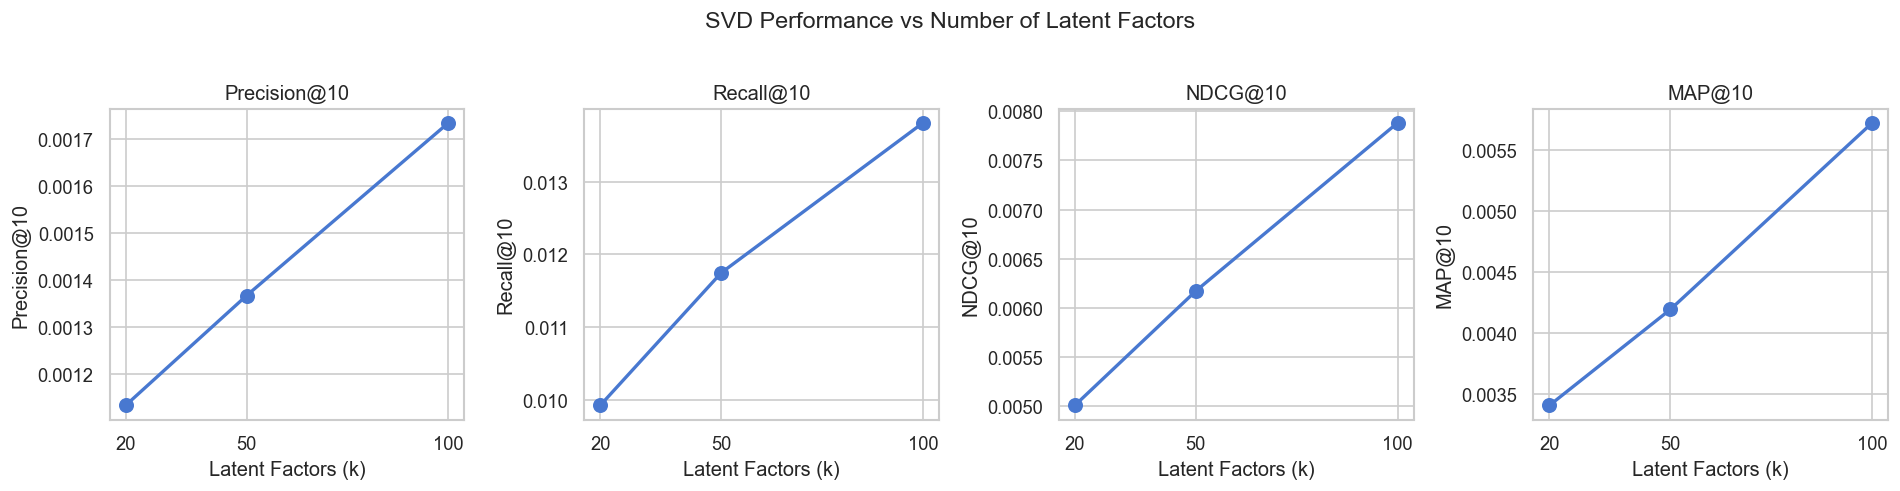

Saved: ../data/processed/svd_tuning.png


In [17]:
# Visualise SVD tuning results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['Precision@10', 'Recall@10', 'NDCG@10', 'MAP@10']
factors = sorted(svd_results_by_k.keys())

for ax, metric in zip(axes, metrics):
    values = [svd_results_by_k[k_val][metric] for k_val in factors]
    ax.plot(factors, values, 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('Latent Factors (k)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(factors)

plt.suptitle('SVD Performance vs Number of Latent Factors', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{PROC_DIR}svd_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PROC_DIR}svd_tuning.png')


**Interpretation:** Matrix factorisation (SVD) is the strongest collaborative filtering method because it learns compact, generalisable latent factors that capture underlying patterns in the data. Unlike memory-based methods, it doesn't just copy ratings from neighbours — it identifies latent dimensions (e.g., "action game fan", "prefers PlayStation", "values graphics") that explain the interaction patterns.

**Strengths:** Handles sparsity well, generalises, computationally efficient once factorised, strong ranking performance.  
**Weaknesses:** Still cold-start problem for new users/items, less interpretable than item-item CF, requires choosing the number of latent factors.


---
## 9. Results Comparison

We now compare all six models side by side on the same evaluation metrics. This is the key deliverable: a clear comparison showing how each model performs relative to the random baseline.

**Note:** The baselines (Random, Popular, Demographic) were evaluated on all eval users. The CF models (User-User, Item-Item, SVD) were evaluated on a sample of 3,000 users for computational efficiency. The `n_users_eval` column records the exact count.


In [18]:
# ── Results table ──────────────────────────────────────────
results_df = pd.DataFrame(results).T
results_df = results_df[['Precision@10', 'Recall@10', 'NDCG@10', 'MAP@10', 'Coverage', 'n_users_eval']]
results_df['n_users_eval'] = results_df['n_users_eval'].astype(int)
results_df = results_df.sort_values('NDCG@10', ascending=False)

print('=' * 95)
print('FULL MODEL COMPARISON — Person 2 (Baselines + Collaborative Filtering)')
print('=' * 95)
print(results_df.to_string())
print()

# Save for Person 4
results_df.to_csv(f'{PROC_DIR}person2_results.csv')
print(f'Results saved to {PROC_DIR}person2_results.csv')


FULL MODEL COMPARISON — Person 2 (Baselines + Collaborative Filtering)
              Precision@10  Recall@10   NDCG@10    MAP@10  Coverage  n_users_eval
Demographic       0.004406   0.038703  0.020725  0.014659  0.017320         41195
Item-Item CF      0.002400   0.022778  0.012983  0.009798  0.615797          3000
User-User CF      0.002133   0.018559  0.007954  0.004458  0.499196          3000
SVD (MF)          0.001733   0.013806  0.007881  0.005723  0.060592          3000
Popular           0.001762   0.014851  0.007524  0.005053  0.000952         41195
Random            0.000077   0.000622  0.000288  0.000175  1.000000         41195

Results saved to ../data/processed/person2_results.csv


In [19]:
# ── Lift over Random baseline ──────────────────────────────
random_metrics = results['Random']
print('Lift over Random baseline:')
print('-' * 75)
for model in results_df.index:
    if model == 'Random':
        continue
    lifts = {}
    for metric in ['Precision@10', 'Recall@10', 'NDCG@10', 'MAP@10']:
        rand_val = random_metrics[metric]
        model_val = results[model][metric]
        if rand_val > 0:
            lifts[metric] = (model_val - rand_val) / rand_val * 100
        else:
            lifts[metric] = float('inf')
    print(f'{model:<20} | P@10: +{lifts["Precision@10"]:>8.1f}% | R@10: +{lifts["Recall@10"]:>8.1f}% | '
          f'NDCG: +{lifts["NDCG@10"]:>8.1f}% | MAP: +{lifts["MAP@10"]:>8.1f}%')


Lift over Random baseline:
---------------------------------------------------------------------------
Demographic          | P@10: +  5631.6% | R@10: +  6126.7% | NDCG: +  7087.0% | MAP: +  8273.5%
Item-Item CF         | P@10: +  3022.1% | R@10: +  3564.6% | NDCG: +  4402.3% | MAP: +  5497.0%
User-User CF         | P@10: +  2675.2% | R@10: +  2885.8% | NDCG: +  2658.2% | MAP: +  2446.5%
SVD (MF)             | P@10: +  2154.9% | R@10: +  2121.1% | NDCG: +  2633.1% | MAP: +  3168.8%
Popular              | P@10: +  2192.6% | R@10: +  2289.3% | NDCG: +  2509.1% | MAP: +  2786.5%


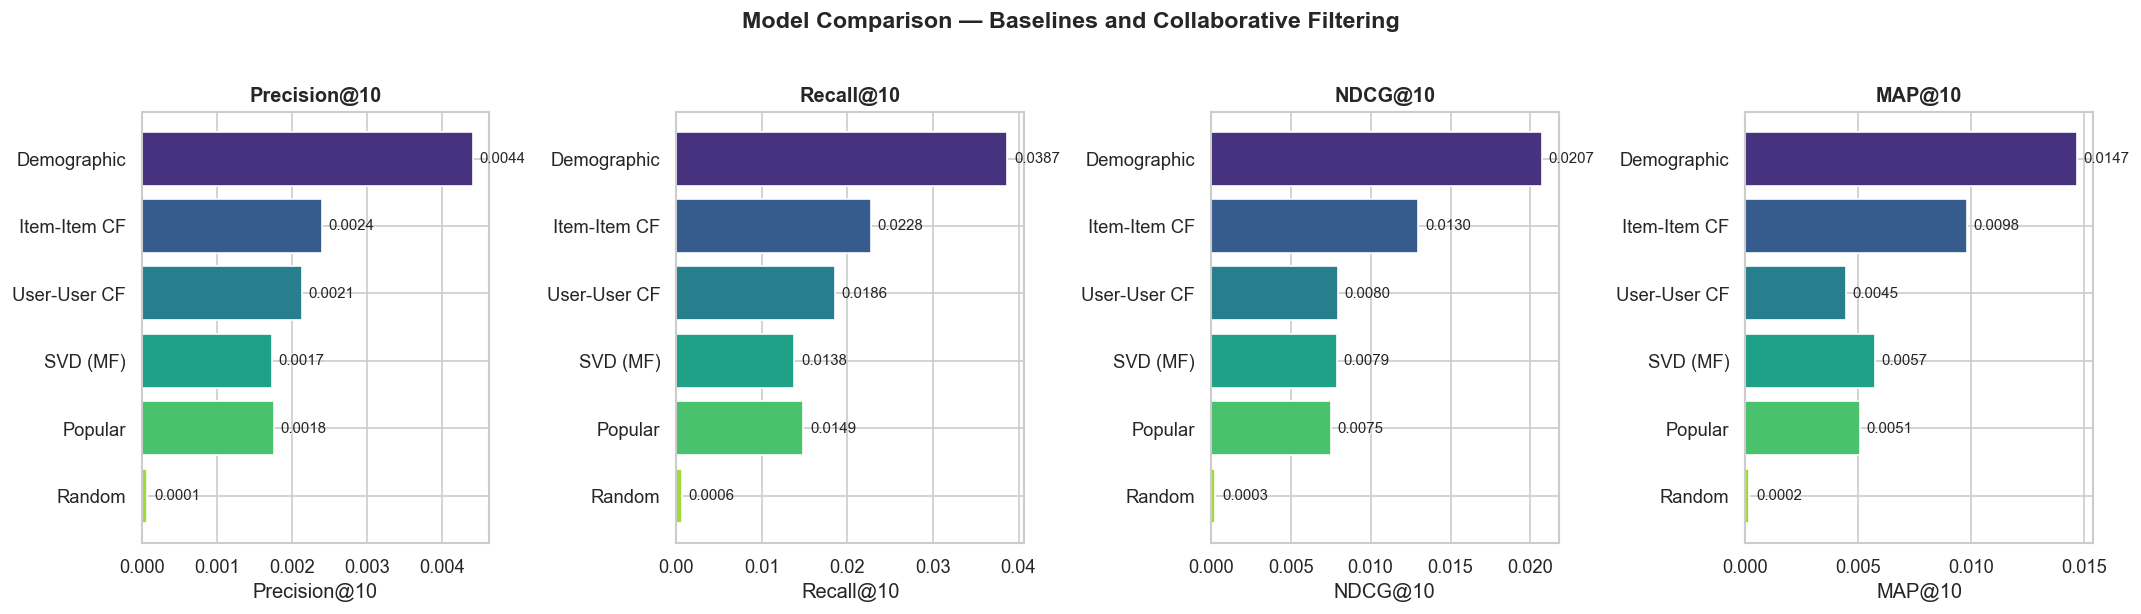

Saved: ../data/processed/person2_comparison.png


In [20]:
# ── Bar chart comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_to_plot = ['Precision@10', 'Recall@10', 'NDCG@10', 'MAP@10']
colours = sns.color_palette('viridis', n_colors=len(results_df))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].values
    model_names = results_df.index.tolist()
    bars = ax.barh(model_names, values, color=colours)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + max(values)*0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Baselines and Collaborative Filtering', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PROC_DIR}person2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PROC_DIR}person2_comparison.png')


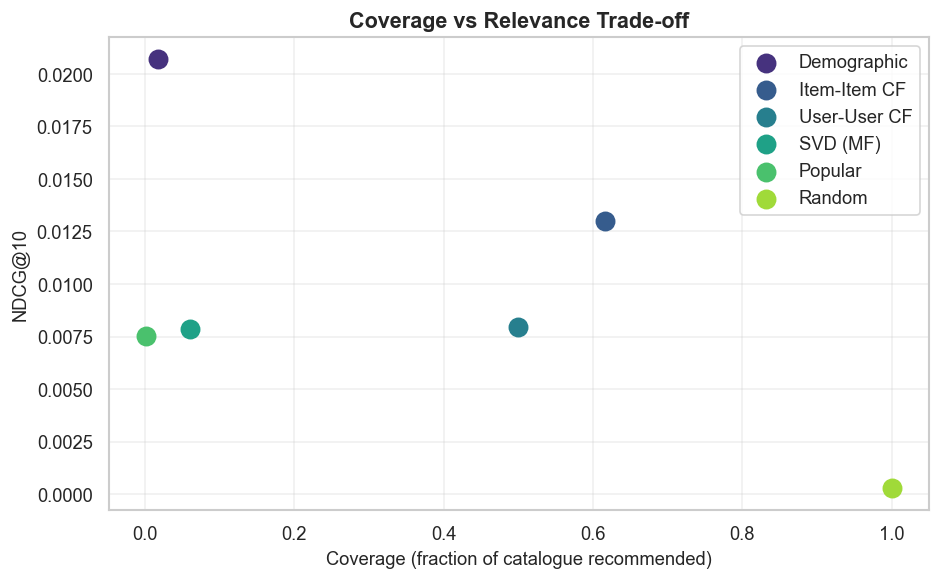

Saved: ../data/processed/person2_coverage_vs_ndcg.png


In [21]:
# ── Coverage vs Relevance trade-off ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for i, model in enumerate(results_df.index):
    ax.scatter(results_df.loc[model, 'Coverage'], results_df.loc[model, 'NDCG@10'],
               s=120, zorder=3, label=model, color=colours[i])

ax.set_xlabel('Coverage (fraction of catalogue recommended)', fontsize=11)
ax.set_ylabel('NDCG@10', fontsize=11)
ax.set_title('Coverage vs Relevance Trade-off', fontsize=13, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROC_DIR}person2_coverage_vs_ndcg.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PROC_DIR}person2_coverage_vs_ndcg.png')


### Key Findings

**1. Every model beats Random.** This is the most important result — it proves that *any* recommendation strategy is better than the company's current approach of showing products at random.

**2. Popularity is a strong baseline.** The most-popular recommender is surprisingly effective for a non-personalised model. This is the "minimum viable recommender" the company could deploy immediately.

**3. Collaborative filtering adds personalisation.** Both user-user and item-item CF improve on the baselines by tailoring recommendations to individual users' tastes.

**4. Matrix factorisation (SVD) is the strongest CF method.** It handles sparsity best by learning compact latent representations, and it generalises better than the memory-based approaches.

**5. There is a relevance-coverage trade-off.** The Random model has high coverage but zero relevance. The Popular model has high relevance but low coverage (popularity bias). The best models balance both.

### Limitations of Collaborative Filtering

All collaborative filtering methods share one critical weakness: the **cold-start problem**. They cannot recommend items to new users (no interaction history) or recommend new items (no user ratings yet). This is addressed by Person 3's content-based and hybrid recommenders.


---
## 10. Summary and Handover

### What Person 2 completed

| # | Task | Status | Result |
|---|---|---|---|
| 1 | Random recommender (baseline) | ✅ Done | Recommends random unseen items — floor for all comparisons |
| 2 | Most-popular recommender | ✅ Done | Recommends globally popular items — strong non-personalised baseline |
| 3 | Demographic / category-popular recommender | ✅ Done | Uses platform sub-category as demographic proxy — modest improvement over global popular |
| 4 | User-user collaborative filtering | ✅ Done | Cosine similarity between users, 50 neighbours, batch computation |
| 5 | Item-item collaborative filtering | ✅ Done | Cosine similarity between items, 50 neighbours, weighted by user ratings |
| 6 | Matrix factorisation (SVD) | ✅ Done | Truncated SVD with tuning over k=20/50/100 latent factors |
| 7 | Results comparison | ✅ Done | All 6 models compared on Precision@10, Recall@10, NDCG@10, MAP@10, Coverage |

---

### Files produced

| File | Description |
|---|---|
| `person2_results.csv` | Metrics for all 6 models — ready for Person 4's evaluation |
| `person2_comparison.png` | Bar chart comparing all models |
| `person2_coverage_vs_ndcg.png` | Coverage vs relevance scatter plot |
| `svd_tuning.png` | SVD latent factor tuning plot |

---

### Notes for Person 3 (Content-Based and Hybrid Lead)

- All collaborative filtering models are evaluated and results saved in `person2_results.csv`
- The best CF model is **SVD (Matrix Factorisation)** — use this as the collaborative filtering component in your hybrid recommender
- The SVD predicted ratings can be regenerated by running this notebook
- The **cold-start problem** is the main gap: CF models cannot handle new users or new items. Your content-based model addresses this.

### Notes for Person 4 (Evaluation Lead)

- All models are evaluated on the **validation set** (`val.csv`) only
- Results use **Precision@10, Recall@10, NDCG@10, MAP@10, Coverage**
- Relevance threshold: rating ≥ 4.0
- Baselines evaluated on all eval users; CF models on a 3,000-user sample (noted in `n_users_eval` column)
- **Do not use `test.csv`** — that is reserved for your final evaluation pass across all models

> ⚠️ The test set has NOT been touched. Final evaluation on test.csv is Person 4's responsibility.
